<a href="https://colab.research.google.com/github/pikey-msc/AprendizMaquina/blob/main/2026-2/Arbol_decisi%C3%B3n_python.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Árboles de decisión
Los **árboles de decisión** son modelos supervisados de clasificación y regresión que ofrecen varias ventajas clave:

### 🔹 Ventajas de los Árboles de Decisión
1. **Interpretabilidad**: Fácil de visualizar y entender.
2. **No linealidad**: No requieren que las relaciones entre variables sean lineales.
3. **Manejo de valores faltantes**: Pueden trabajar con datos incompletos sin imputaciones.
4. **Adaptabilidad a datos mixtos**: Funcionan con variables **categóricas y continuas** son más visuales en R.
5. **No requieren estandarización**: No dependen de la escala de las variables.
6. **Eficiencia computacional**: Algoritmos como **CART** o **ID3** permiten una construcción rápida.

Sin embargo, también presentan desventajas:
- **Propensos a overfitting** en datos pequeños.
- **Menos precisos** en comparación con métodos como **Random Forest o XGBoost**.
- **Sensibles a cambios en los datos** (alta varianza).

Los **árboles de decisión** son un tipo de modelo de aprendizaje supervisado utilizado para **clasificación y regresión**. Se basan en la partición recursiva del espacio de características, seleccionando en cada nodo la mejor división según un criterio como:
- **Information Gain (Entropía)**
- **Índice de Gini**
- **Twoing (para árboles binarios)**
- **Reducción del Error Cuadrático Medio (para regresión)**

## 🔹  Algoritmo Teórico
1. **Inicialización**: Se parte de un conjunto de datos $ D $ con una variable objetivo $ Y $ y múltiples variables predictoras $ X $.
2. **Criterio de División**: Se elige el mejor atributo $ X_j $ que maximiza la separación de los datos según un criterio (IG, Gini, etc.).
3. **División Recursiva**: Se crean nodos hijos con los subconjuntos de datos generados por la partición.
4. **Criterio de Detención**:
   - Si todos los datos en un nodo pertenecen a la misma clase.
   - Si el número de muestras en el nodo es menor que un umbral.
   - Si la ganancia de información es mínima.
5. **Poda (opcional)**: Se elimina ruido y reduce overfitting mediante poda pre-pruning (criterios de detención) o post-pruning (reducción de ramas con validación cruzada).

---
## 1. Fundamentos Teóricos

### 1.1 Formalización del problema

Sea $\mathcal{D} = \{(\mathbf{x}_i, y_i)\}_{i=1}^n$ un conjunto de entrenamiento donde $\mathbf{x}_i \in \mathbb{R}^p$ y $y_i \in \mathcal{Y}$.
Un árbol de decisión $T$ es una función $T: \mathbb{R}^p \to \mathcal{Y}$ construida mediante **particiones recursivas binarias** del espacio de características.

En cada nodo interno se resuelve:
$$j^*, t^* = \arg\max_{j,t} \; \Delta I(S, j, t)$$
donde $\Delta I$ es la **reducción de impureza** al dividir el conjunto $S$ por el atributo $j$ en el umbral $t$.

---

### 1.2 Criterios de División

#### a) Entropía de Shannon — usado en ID3 y C4.5
$$H(S) = -\sum_{k=1}^{C} p_k \log_2 p_k$$

**Ganancia de Información:**
$$IG(S, A) = H(S) - \sum_{v \in \text{Val}(A)} \frac{|S_v|}{|S|} H(S_v)$$

**Nota:** $H(S) \in [0, \log_2 C]$. $H = 0$ ⟹ nodo puro; $H = \log_2 C$ ⟹ distribución uniforme (máxima incertidumbre).

#### b) Índice de Gini — usado en CART
$$\text{Gini}(S) = 1 - \sum_{k=1}^{C} p_k^2 = \sum_{k \neq k'} p_k p_{k'}$$

Interpretación: probabilidad de clasificar incorrectamente un elemento elegido al azar si se etiqueta aleatoriamente según la distribución de clases.

#### c) Twoing — para árboles binarios
$$\text{Twoing}(S, A) = \frac{1}{4} \left(\sum_{k=1}^{C} |P_L(k) - P_R(k)|\right)^2$$
donde $P_L(k)$ y $P_R(k)$ son las proporciones de clase $k$ en los hijos izquierdo y derecho.

---

### 1.3 Reducción de Varianza — para regresión
$$\Delta V(S, j, t) = \text{Var}(S) - \frac{|S_L|}{|S|}\text{Var}(S_L) - \frac{|S_R|}{|S|}\text{Var}(S_R)$$

El nodo predice $\hat{y} = \bar{y}_{\text{nodo}}$ (media de las observaciones en esa hoja).

---

### 1.4 ¿Por qué R para variables categóricas?

`rpart` en R puede dividir sobre variables categóricas **directamente**, explorando $2^{C-1} - 1$ subconjuntos posibles de categorías. `sklearn` en Python **no soporta** variables categóricas nativas — requiere encoding previo (OHE o Label), lo que distorsiona la estructura de las divisiones.

**Demostración del problema en Python (bug intencional para ilustrar):**



## 🔹 Fórmulas de Criterios de División
### a) Information Gain (Entropía)
$$
IG(S, A) = H(S) - \sum_{v \in \text{Valores}(A)} \frac{|S_v|}{|S|} H(S_v)
$$
donde la **entropía** se define como:
$$
H(S) = -\sum_{i=1}^{C} p_i \log_2 p_i
$$

### b) Índice de Gini
$$
Gini(S) = 1 - \sum_{i=1}^{C} p_i^2
$$

### c) Twoing
$$
Twoing(S, A) = \sum_{v \in \text{Valores}(A)} \frac{|S_v|}{|S|} \left| P_{left} - P_{right} \right|
$$

---


## **Otros Algoritmos**
Existen diversos algoritmos para solucionar el problema anterior, cada uno utiliza metodologías distintas para particionar los datos así como para definir el criterio de paro del algorimo.
* ID3
* C4.5

**Elementos**\
Un árbol de decisión está formado por un conjunto de nodos de decisión (interiores) y de nodos-respuesta (hojas):
* Un nodo de decisión está asociado a uno de los atributos y tiene 2 o más ramas que salen de él, cada una de ellas representando los posibles valores que puede tomar el atributo asociado. De alguna forma, un nodo de decisión es como una pregunta que se le hace al ejemplo analizado, y dependiendo de la respuesta que de, el flujo tomará una de las ramas salientes.
* Un nodo-respuesta está asociado a la clasificación que se quiere proporcionar, y nos devuelve la decisión del árbol con respecto al ejemplo de entrada.

**ID3**\
El ID3 construye un árbol de decisión de arriba a abajo, de forma directa, sin hacer uso de backtracking, y basándose únicamente en los ejemplos iniciales proporcionados. Para ello, usa el concepto de Ganancia de Información para seleccionar el atributo más útil en cada paso.\
En cierta forma, sigue un método voraz para decidir la pregunta que mayor ganancia da en cada paso, es decir, aquella que me permite separar mejor los ejemplos entre sí respecto a la clasificación final.

**Informacion**\
La medida que se utiliza se llama entropía y se utiliza para clasificar los elementos procurando:
* Muestra completamente homogénea (es decir, en la que todos se clasifican igual).En este caso, fijaremos la incertidumbre (entropía) a 0
* Muestra igualmente distribuida, es decir, que tiene el mismo número de ejemplos.En este caso, fijaremos la incertidumbre (entropía) a 1

Para medir la incertidumbre de un sistema. Shannon llega a la conclusión de que la mejor función matemática que mide este grado de incertidumbre es la siguiente:

$$\textrm{Information Gain}=IG=\sum_{i=1}^c -p_ilog_2(p_i)$$

donde $S$ es el conjunto de muestras (el sistema analizado), $C$ es el número de diferentes clasificaciones que usamos, y cada $p_i$ es la proporción de ejemplos que hay de la clasificación $i$ en la muestra.

**Ejemplo teórico**\
El algoritmo ID3 se ejecuta recursivamente en nodos que no sean de respuesta (hojas) hasta llegar al caso de entropía nula.
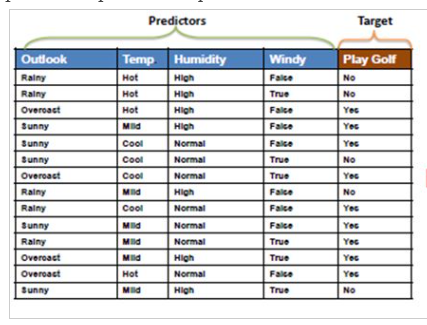

In [ ]:
import numpy as np
import pandas as pd
from collections import Counter
import math

# Definir el conjunto de datos
data = [
    ["Rainy", "Hot", "High", False, "No"],
    ["Rainy", "Hot", "High", True, "No"],
    ["Overcast", "Hot", "High", False, "Yes"],
    ["Sunny", "Mild", "High", False, "Yes"],
    ["Sunny", "Cool", "Normal", False, "Yes"],
    ["Sunny", "Cool", "Normal", True, "No"],
    ["Overcast", "Cool", "Normal", True, "Yes"],
    ["Rainy", "Mild", "High", False, "Yes"],
    ["Rainy", "Cool", "Normal", False, "Yes"],
    ["Sunny", "Mild", "Normal", False, "Yes"],
    ["Rainy", "Mild", "Normal", True, "No"],
    ["Overcast", "Mild", "High", True, "Yes"],
    ["Overcast", "Hot", "Normal", False, "Yes"],
    ["Sunny", "Mild", "High", True, "No"]
]

# Convertir en DataFrame
columns = ["Outlook", "Temp", "Humidity", "Windy", "Play Golf"]
df = pd.DataFrame(data, columns=columns)

# Función para calcular la entropía
def entropy(y):
    counts = Counter(y)
    total = len(y)
    return -sum((count/total) * math.log2(count/total) for count in counts.values())

# Función para calcular el Information Gain
def information_gain(data, feature, target="Play Golf"):
    total_entropy = entropy(data[target])
    values = data[feature].unique()
    weighted_entropy = sum((len(data[data[feature] == value]) / len(data)) * entropy(data[data[feature] == value][target])
                           for value in values)
    return total_entropy - weighted_entropy

# Elegir el mejor atributo dividiendo por IG
def best_feature(data, target="Play Golf"):
    features = [col for col in data.columns if col != target]
    gains = {feature: information_gain(data, feature, target) for feature in features}
    print("\nInformation Gain de cada atributo:")
    for key, value in gains.items():
        print(f"{key}: {value:.4f}")
    return max(gains, key=gains.get)

# Construcción del árbol de decisión
def build_tree(data, target="Play Golf"):
    if len(set(data[target])) == 1:
        return data[target].iloc[0]
    if len(data.columns) == 1:
        return Counter(data[target]).most_common(1)[0][0]

    best = best_feature(data, target)
    tree = {best: {}}
    print(f"\nDividiendo en el atributo: {best}")

    for value in data[best].unique():
        subset = data[data[best] == value].drop(columns=[best])
        tree[best][value] = build_tree(subset, target)

    return tree

# Construir el árbol
decision_tree = build_tree(df)

# Imprimir el árbol construido
import pprint
print("\nÁrbol de Decisión:")
pprint.pprint(decision_tree)



Information Gain de cada atributo:
Outlook: 0.2467
Temp: 0.0292
Humidity: 0.0161
Windy: 0.2361

Dividiendo en el atributo: Outlook

Information Gain de cada atributo:
Temp: 0.5710
Humidity: 0.0200
Windy: 0.4200

Dividiendo en el atributo: Temp

Information Gain de cada atributo:
Humidity: 1.0000
Windy: 1.0000

Dividiendo en el atributo: Humidity

Information Gain de cada atributo:
Temp: 0.0200
Humidity: 0.0200
Windy: 0.9710

Dividiendo en el atributo: Windy

Árbol de Decisión:
{'Outlook': {'Overcast': 'Yes',
             'Rainy': {'Temp': {'Cool': 'Yes',
                                'Hot': 'No',
                                'Mild': {'Humidity': {'High': 'Yes',
                                                      'Normal': 'No'}}}},
             'Sunny': {'Windy': {False: 'Yes', True: 'No'}}}}


# Gini y twoing

In [ ]:

# Función para calcular el índice de Gini
def gini(y):
    counts = Counter(y)
    total = len(y)
    return 1 - sum((count/total) ** 2 for count in counts.values())

# Función para calcular Twoing
def twoing(data, feature, target="Play Golf"):
    total_samples = len(data)
    values = data[feature].unique()
    twoing_score = 0

    for value in values:
        subset = data[data[feature] == value]
        proportion = len(subset) / total_samples
        target_counts = Counter(subset[target])
        total_subset = len(subset)

        prob_left = target_counts["Yes"] / total_subset if "Yes" in target_counts else 0
        prob_right = target_counts["No"] / total_subset if "No" in target_counts else 0

        twoing_score += proportion * abs(prob_left - prob_right)

    return twoing_score

# Función para calcular la ganancia usando Gini
def gini_gain(data, feature, target="Play Golf"):
    total_gini = gini(data[target])
    values = data[feature].unique()
    weighted_gini = sum((len(data[data[feature] == value]) / len(data)) * gini(data[data[feature] == value][target])
                        for value in values)
    return total_gini - weighted_gini

# Elegir el mejor atributo dividiendo por Gini y Twoing
def best_feature(data, target="Play Golf"):
    features = [col for col in data.columns if col != target]
    gini_gains = {feature: gini_gain(data, feature, target) for feature in features}
    twoing_scores = {feature: twoing(data, feature, target) for feature in features}

    print("\nValores de Gini Gain y Twoing para cada atributo:")
    for key in gini_gains.keys():
        print(f"{key}: Gini Gain = {gini_gains[key]:.4f}, Twoing = {twoing_scores[key]:.4f}")

    # Selección basada en el mejor Gini Gain
    return max(gini_gains, key=gini_gains.get)

# Construcción del árbol de decisión
def build_tree(data, target="Play Golf"):
    if len(set(data[target])) == 1:
        return data[target].iloc[0]
    if len(data.columns) == 1:
        return Counter(data[target]).most_common(1)[0][0]

    best = best_feature(data, target)
    tree = {best: {}}
    print(f"\nDividiendo en el atributo: {best}")

    for value in data[best].unique():
        subset = data[data[best] == value].drop(columns=[best])
        tree[best][value] = build_tree(subset, target)

    return tree

# Construir el árbol
decision_tree = build_tree(df)

# Imprimir el árbol construido
import pprint
print("\nÁrbol de Decisión:")
pprint.pprint(decision_tree)


Valores de Gini Gain y Twoing para cada atributo:
Outlook: Gini Gain = 0.1163, Twoing = 0.4286
Temp: Gini Gain = 0.0187, Twoing = 0.2857
Humidity: Gini Gain = 0.0102, Twoing = 0.2857
Windy: Gini Gain = 0.1437, Twoing = 0.5714

Dividiendo en el atributo: Windy

Valores de Gini Gain y Twoing para cada atributo:
Outlook: Gini Gain = 0.0521, Twoing = 0.7500
Temp: Gini Gain = 0.0521, Twoing = 0.7500
Humidity: Gini Gain = 0.0312, Twoing = 0.7500

Dividiendo en el atributo: Outlook

Valores de Gini Gain y Twoing para cada atributo:
Temp: Gini Gain = 0.4444, Twoing = 1.0000
Humidity: Gini Gain = 0.1111, Twoing = 0.3333

Dividiendo en el atributo: Temp

Valores de Gini Gain y Twoing para cada atributo:
Outlook: Gini Gain = 0.4444, Twoing = 1.0000
Temp: Gini Gain = 0.0556, Twoing = 0.3333
Humidity: Gini Gain = 0.0000, Twoing = 0.3333

Dividiendo en el atributo: Outlook

Árbol de Decisión:
{'Windy': {False: {'Outlook': {'Overcast': 'Yes',
                               'Rainy': {'Temp': {'Cool':

🔹 1. Criterios para Evaluar el Mejor Algoritmo
1. Para elegir entre Information Gain (IG), Gini Gain y Twoing, debemos considerar:

2. Precisión en la clasificación 📊 → ¿Qué criterio genera un árbol con mejor capacidad predictiva?

2. Profundidad del árbol 🌳 → ¿Qué algoritmo genera un árbol más simple y menos propenso a overfitting?

3. Balance de clases ⚖️ → ¿El algoritmo produce divisiones equilibradas entre categorías?
4. Tiempo de ejecución ⏳ → ¿Qué método es más eficiente?

El mejor algoritmo será aquel que equilibre estos factores y genere un modelo preciso y generalizable.

## Ejemplo ya usando estos datos

In [ ]:
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Definir el conjunto de datos
data = [
    ["Rainy", "Hot", "High", False, "No"],
    ["Rainy", "Hot", "High", True, "No"],
    ["Overcast", "Hot", "High", False, "Yes"],
    ["Sunny", "Mild", "High", False, "Yes"],
    ["Sunny", "Cool", "Normal", False, "Yes"],
    ["Sunny", "Cool", "Normal", True, "No"],
    ["Overcast", "Cool", "Normal", True, "Yes"],
    ["Rainy", "Mild", "High", False, "Yes"],
    ["Rainy", "Cool", "Normal", False, "Yes"],
    ["Sunny", "Mild", "Normal", False, "Yes"],
    ["Rainy", "Mild", "Normal", True, "No"],
    ["Overcast", "Mild", "High", True, "Yes"],
    ["Overcast", "Hot", "Normal", False, "Yes"],
    ["Sunny", "Mild", "High", True, "No"]
]

# Convertir en DataFrame
columns = ["Outlook", "Temp", "Humidity", "Windy", "Play Golf"]
df = pd.DataFrame(data, columns=columns)

# Codificar variables categóricas a numéricas
label_encoders = {}
for col in ["Outlook", "Temp", "Humidity", "Windy", "Play Golf"]:
    label_encoders[col] = LabelEncoder()
    df[col] = label_encoders[col].fit_transform(df[col])

# Separar en variables predictoras (X) y variable objetivo (y)
X = df.drop(columns=["Play Golf"])
y = df["Play Golf"]

# Dividir en entrenamiento y prueba (80% - 20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=1, random_state=42)

# Entrenar árboles con diferentes criterios
criterios = ["entropy", "gini"]
resultados = {}

for criterio in criterios:
    model = DecisionTreeClassifier(criterion=criterio, random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)

    print(f"\nÁrbol entrenado con {criterio}:")
    print(export_text(model, feature_names=list(X.columns)))

    resultados[criterio] = accuracy

# Twoing (no soportado por sklearn, pero se simula con una métrica de balance)
# En este caso, simplemente mostramos Gini para referencia.

# Comparar resultados
print("\nComparación de Accuracy:")
for criterio, acc in resultados.items():
    print(f"{criterio}: {acc:.4f}")




Árbol entrenado con entropy:
|--- Outlook <= 0.50
|   |--- class: 1
|--- Outlook >  0.50
|   |--- Windy <= 0.50
|   |   |--- Humidity <= 0.50
|   |   |   |--- Temp <= 1.50
|   |   |   |   |--- class: 0
|   |   |   |--- Temp >  1.50
|   |   |   |   |--- class: 1
|   |   |--- Humidity >  0.50
|   |   |   |--- class: 1
|   |--- Windy >  0.50
|   |   |--- class: 0


Árbol entrenado con gini:
|--- Windy <= 0.50
|   |--- Humidity <= 0.50
|   |   |--- Temp <= 1.50
|   |   |   |--- Outlook <= 0.50
|   |   |   |   |--- class: 1
|   |   |   |--- Outlook >  0.50
|   |   |   |   |--- class: 0
|   |   |--- Temp >  1.50
|   |   |   |--- class: 1
|   |--- Humidity >  0.50
|   |   |--- class: 1
|--- Windy >  0.50
|   |--- Outlook <= 0.50
|   |   |--- class: 1
|   |--- Outlook >  0.50
|   |   |--- class: 0


Comparación de Accuracy:
entropy: 1.0000
gini: 1.0000


Twoing no está implementado en sklearn, pero si Gini genera divisiones balanceadas, podemos inferir que Twoing sería similar.

### Comparación entre Information Gain, Gini Gain y Twoing

| **Criterio**       | **Information Gain** | **Gini Gain** | **Twoing** |
|--------------------|---------------------|--------------|-----------|
| **Velocidad**      | Más lento           | Más rápido   | Intermedio |
| **Overfitting**    | Más probable        | Menos probable | Menos probable |
| **Balance de clases** | No lo considera  | No lo considera | Sí lo considera |
| **Uso común**      | ID3, C4.5           | CART         | Árboles binarios avanzados |
| **Mejor para...**  | Categóricos, máxima información | Datos mixtos, velocidad | Divisiones más balanceadas |
| **Cuándo usarlo**  | Datos categóricos, cuando se busca maximizar la reducción de incertidumbre | Datos mixtos (numéricos y categóricos), cuando se busca rapidez y robustez | Cuando se necesita un árbol estrictamente binario con divisiones balanceadas |
| **Ventajas**       | Mide reducción de incertidumbre, útil en datos categóricos | Más rápido, favorece separaciones balanceadas, menos propenso a overfitting | Favorece balance en las divisiones, no sesga hacia atributos con muchos valores únicos |
| **Desventajas**    | Puede dar preferencia a atributos con muchos valores únicos, más lento | No considera la distribución de clases como la entropía | Más complejo de interpretar, más costoso computacionalmente |


Conclusión
* Si te importa la precisión teórica, usa Information Gain.
* Si necesitas eficiencia y robustez, usa Gini Gain.
* Si buscas balance y buenas separaciones binarias, usa Twoing.


¿Cuál elegir?
* Si trabajas con CART o datasets grandes, Gini Gain es la mejor opción.
* Si prefieres mejor separación de clases, usa Twoing.
* Si quieres evitar la incertidumbre máxima, Information Gain es tu opción. 🚀

## 🔹 Dataset: Predicción de Admisión Universitaria
Usaremos un dataset con las siguientes variables:
- **Categóricas**: Universidad (Baja, Media, Alta), Carta de Recomendación (Mala, Buena, Excelente)
- **Continuas**: Puntaje de examen (0-100), GPA (0-4.0)
- **Variable Objetivo**: Admitido (Sí/No)


In [ ]:
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Crear dataset
data = {
    "Universidad": ["Alta", "Media", "Baja", "Alta", "Media", "Baja", "Alta", "Baja", "Media", "Alta"],
    "Carta_Recomendacion": ["Buena", "Mala", "Excelente", "Buena", "Mala", "Buena", "Excelente", "Buena", "Mala", "Excelente"],
    "Puntaje_Examen": [85, 60, 90, 75, 50, 78, 92, 65, 55, 89],
    "GPA": [3.8, 2.5, 3.9, 3.4, 2.1, 3.3, 4.0, 2.8, 2.4, 3.7],
    "Admitido": ["Sí", "No", "Sí", "Sí", "No", "Sí", "Sí", "No", "No", "Sí"]
}


df = pd.DataFrame(data)
print(df.head(3))

# Codificar variables categóricas
label_encoders = {}
for col in ["Universidad", "Carta_Recomendacion", "Admitido"]:
    label_encoders[col] = LabelEncoder()
    df[col] = label_encoders[col].fit_transform(df[col])

# Separar variables predictoras y objetivo
X = df.drop(columns=["Admitido"])
y = df["Admitido"]

# Dividir en datos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=1, random_state=42)

df.head(3)

  Universidad Carta_Recomendacion  Puntaje_Examen  GPA Admitido
0        Alta               Buena              85  3.8       Sí
1       Media                Mala              60  2.5       No
2        Baja           Excelente              90  3.9       Sí


,Universidad,Carta_Recomendacion,Puntaje_Examen,GPA,Admitido
0,0,0,85,3.8,1
1,2,2,60,2.5,0
2,1,1,90,3.9,1


In [ ]:
criterios = ["entropy", "gini"]
resultados = {}

for criterio in criterios:
    model = DecisionTreeClassifier(criterion=criterio, random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)

    print(f"\nÁrbol entrenado con {criterio}:")
    print(export_text(model, feature_names=list(X.columns)))

    resultados[criterio] = accuracy

# Mostrar comparación de accuracy
print("\nComparación de Accuracy:")
for criterio, acc in resultados.items():
    print(f"{criterio}: {acc:.4f}")

ValueError: could not convert string to float: 'Media'

In [ ]:
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeClassifier

# Crear dataset con variables categóricas y continuas
data = pd.DataFrame({
    "Universidad": ["Alta", "Media", "Baja", "Alta", "Media", "Baja", "Alta", "Baja", "Media", "Alta"],
    "Carta_Recomendacion": ["Buena", "Mala", "Excelente", "Buena", "Mala", "Buena", "Excelente", "Buena", "Mala", "Excelente"],
    "Puntaje_Examen": [85, 60, 90, 75, 50, 78, 92, 65, 55, 89],  # Variable continua
    "GPA": [3.8, 2.5, 3.9, 3.4, 2.1, 3.3, 4.0, 2.8, 2.4, 3.7],  # Variable continua
    "Admitido": ["Sí", "No", "Sí", "Sí", "No", "Sí", "Sí", "No", "No", "Sí"]  # Variable objetivo
})

# Convertir variables categóricas a tipo 'category'
for col in ["Universidad", "Carta_Recomendacion", "Admitido"]:
    data[col] = data[col].astype("category")

# Guardar los mapeos de categorías para revertir los códigos
category_mappings = {col: dict(enumerate(data[col].cat.categories)) for col in ["Universidad", "Carta_Recomendacion"]}

# Convertir variables categóricas a códigos numéricos
X = data[["Universidad", "Carta_Recomendacion"]].copy()
y = data["Admitido"].copy()

for col in ["Universidad", "Carta_Recomendacion"]:
    X[col] = X[col].cat.codes

# **FORZAR que el árbol maneje categorías como variables discretas**
tree = DecisionTreeClassifier(criterion="entropy", random_state=42, min_samples_split=2, min_samples_leaf=1)
tree.fit(X, y.cat.codes)

# Extraer reglas bien formateadas con variables categóricas reales
def extract_rules(tree, X, y, category_mappings):
    tree_ = tree.tree_
    feature_names = X.columns.tolist()
    rules = []

    def recurse(node, depth):
        indent = "  " * depth
        if tree_.feature[node] != -2:
            feature = feature_names[tree_.feature[node]]
            threshold = tree_.threshold[node]

            # Si la variable es categórica, mostrar el valor original
            if feature in category_mappings:
                category_value = category_mappings[feature][int(threshold + 0.5)]
                rule = f"{indent}Si {feature} == '{category_value}':"
            else:
                rule = f"{indent}Si {feature} <= {threshold:.2f}:"

            rules.append(rule)
            recurse(tree_.children_left[node], depth + 1)
            rules.append(f"{indent}Si NO {rule.split(':')[0]}:")
            recurse(tree_.children_right[node], depth + 1)
        else:
            clase = np.argmax(tree_.value[node])  # Tomar la clase con mayor probabilidad
            rules.append(f"{indent}=> Clase: {['No', 'Sí'][clase]}")

    recurse(0, 0)
    return "\n".join(rules)

# Obtener reglas
rules_output = extract_rules(tree, X, y, category_mappings)

# Imprimir reglas corregidas
print("\n🔥 Reglas de decisión del árbol con categorías reales:")
print(rules_output)



🔥 Reglas de decisión del árbol con categorías reales:
Si Universidad == 'Media':
  Si Universidad == 'Baja':
    => Clase: Sí
  Si NO   Si Universidad == 'Baja':
    Si Carta_Recomendacion == 'Excelente':
      => Clase: No
    Si NO     Si Carta_Recomendacion == 'Excelente':
      => Clase: Sí
Si NO Si Universidad == 'Media':
  => Clase: No


## 📌  Conclusiones

| **Criterio**   | **Information Gain (Entropía)** | **Gini Gain** |
|--------------|----------------------------|--------------|
| **Ventajas** | Máxima separación de clases | Más rápido, menos overfitting |
| **Desventajas** | Puede favorecer atributos con muchos valores únicos | Puede no ser óptimo en datos altamente categóricos |
| **Mejor para...** | Datos puramente categóricos | Datos mixtos (continuos y categóricos) |

✅ **Para este dataset mixto (categóricas + continuas), Gini Gain es más eficiente** y genera **árboles más compactos**.


## 📌¿Por qué no usar otro método como GLM?

Los **Modelos Lineales Generalizados (GLM)** son una alternativa a los árboles de decisión y se utilizan cuando:
- La relación entre la variable dependiente e independiente sigue una **función conocida**.
- Se requiere una estimación **probabilística** de la respuesta.

Sin embargo, **GLM tiene limitaciones**:
1. **Requiere supuestos de linealidad** entre las variables.
2. **No maneja bien datos categóricos complejos sin transformación**.
3. **Menos flexible en problemas con muchas interacciones no lineales**.

### 🔹 Contraejemplo en Python: Comparación entre **GLM y Árboles de Decisión**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Generar datos sintéticos
# np.random.seed(2**6)
X1 = np.random.rand(200) * 10  # Variable continua
X2 = np.random.choice(["A", "B", "C"], size=200)  # Variable categórica
y = (np.random.randn(200)*20 > 5).astype(int)  # Etiquetas binarias

# Convertir variable categórica en variables dummy
df = pd.DataFrame({"X1": X1, "X2": X2, "y": y})
df = pd.get_dummies(df, columns=["X2"], drop_first=True)  # One-hot encoding

# Dividir en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(df.drop(columns=["y"]), df["y"], test_size=0.2, random_state=42)

# Entrenar GLM (Regresión Logística)
glm = LogisticRegression()
glm.fit(X_train, y_train)
y_pred_glm = glm.predict(X_test)

# Entrenar Árbol de Decisión
tree = DecisionTreeClassifier(max_depth=3)
tree.fit(X_train, y_train)
y_pred_tree = tree.predict(X_test)

# Evaluación de modelos
acc_glm = accuracy_score(y_test, y_pred_glm)
acc_tree = accuracy_score(y_test, y_pred_tree)

print(f"Precisión de GLM (Regresión Logística): {acc_glm:.4f}")
print(f"Precisión del Árbol de Decisión: {acc_tree:.4f}")

Precisión de GLM (Regresión Logística): 0.5250
Precisión del Árbol de Decisión: 0.5500


Si la precisión de GLM es menor que la del Árbol de Decisión, significa que la relación no es completamente lineal.
GLM no maneja bien datos categóricos complejos, mientras que el Árbol de Decisión los segmenta naturalmente.

## 📌 ¿Cómo se ajustan los parámetros en árboles de decisión?
El ajuste de parámetros en **árboles de decisión** se puede realizar de dos maneras:

1. **Sin paqueterías**: Implementando la selección de divisiones y poda de manera manual.
2. **Con paqueterías**: Usando bibliotecas como `sklearn` para optimizar hiperparámetros.

Los parámetros clave a ajustar incluyen:
- `max_depth`: Controla la profundidad máxima del árbol.
- `min_samples_split`: Número mínimo de muestras requeridas para dividir un nodo.
- `min_samples_leaf`: Número mínimo de muestras en una hoja.
- `criterion`: Métrica de separación (`gini` o `entropy`).

A continuación, implementamos un algoritmo manual y otro con `sklearn`.

In [ ]:
import numpy as np

# Función para calcular la entropía
def entropy(y):
    values, counts = np.unique(y, return_counts=True)
    probs = counts / counts.sum()
    return -np.sum(probs * np.log2(probs))

# Función para encontrar la mejor división
def best_split(X, y):
    best_feature, best_value, best_gain = None, None, -1
    base_entropy = entropy(y)

    for feature in range(X.shape[1]):
        values = np.unique(X[:, feature])
        for value in values:
            left_mask = X[:, feature] <= value
            right_mask = ~left_mask

            left_entropy = entropy(y[left_mask]) if len(y[left_mask]) > 0 else 0
            right_entropy = entropy(y[right_mask]) if len(y[right_mask]) > 0 else 0
            weighted_entropy = (len(y[left_mask]) * left_entropy + len(y[right_mask]) * right_entropy) / len(y)

            gain = base_entropy - weighted_entropy

            if gain > best_gain:
                best_feature, best_value, best_gain = feature, value, gain

    return best_feature, best_value

# Ejemplo de uso
X = np.array([[2, 3], [4, 5], [6, 2], [8, 7], [10, 1]])
y = np.array([0, 1, 0, 1, 0])

best_feat, best_val = best_split(X, y)
print(f"Mejor división en feature {best_feat} con valor {best_val}")

Mejor división en feature 1 con valor 3


In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.datasets import make_classification

# Generar datos
X, y = make_classification(n_samples=200, n_features=5, random_state=42)

print(y)
# Definir parámetros a optimizar
param_grid = {
    'max_depth': [3, 5, 7],
    'min_samples_split': [2, 4, 6],
    'criterion': ['gini', 'entropy']
}

# Modelo y búsqueda de mejores parámetros
tree = DecisionTreeClassifier(random_state=42)
grid_search = GridSearchCV(tree, param_grid, cv=5)
grid_search.fit(X, y)

print(f"Mejores parámetros: {grid_search.best_params_}")

[0 1 0 1 1 0 0 1 1 1 1 1 1 1 0 1 0 1 1 1 0 0 1 0 0 0 0 0 0 1 1 1 1 0 1 1 1
 1 0 0 0 1 1 0 1 1 0 0 1 0 0 1 0 1 1 1 0 0 1 1 1 1 0 1 0 1 1 0 0 0 1 1 0 0
 0 0 1 0 0 1 0 1 1 1 1 1 0 0 1 1 1 0 0 1 1 0 0 1 0 0 1 0 1 1 1 0 1 0 1 1 1
 0 1 1 0 1 1 1 0 1 0 1 0 1 0 0 0 1 1 0 0 0 1 0 0 1 1 0 0 0 0 0 0 0 1 0 0 1
 1 0 0 0 1 1 1 0 0 0 0 1 0 0 1 1 1 0 0 0 0 1 0 0 1 1 0 1 1 0 0 1 0 0 1 1 1
 1 0 1 1 1 0 1 0 1 0 0 0 0 1 0]
Mejores parámetros: {'criterion': 'entropy', 'max_depth': 5, 'min_samples_split': 6}


## 📌 ¿Qué pruebas de hipótesis se aplican en árboles de decisión?
En árboles de decisión, las pruebas de hipótesis se usan para evaluar si una **división mejora significativamente la predicción**.

### 🔹 Prueba de Chi-Cuadrado
Evalúa si la distribución de clases en los nodos hijos es **significativamente diferente** de la distribución en el nodo padre.

$$ \chi^2 = \sum \frac{(O - E)^2}{E} $$

donde:
- $ O $ = valores observados (frecuencia de clases en los nodos hijos).
- $ E $ = valores esperados si la división fuera aleatoria.

Si $ p < 0.05 $, la división **es significativa** y se justifica mantenerla.

In [ ]:
import scipy.stats as stats
import numpy as np

# Datos de ejemplo (frecuencias observadas en los nodos hijo)
observed = np.array([[30, 10], [20, 40]])  # [Clase 0, Clase 1] en cada nodo hijo

# Calcular Chi-Cuadrado
chi2, p_value, _, _ = stats.chi2_contingency(observed)
print(f"Chi-cuadrado: {chi2:.4f}, p-valor: {p_value:.4f}")

# Evaluar resultado
if p_value < 0.05:
    print("La división es significativa (se justifica mantenerla).")
else:
    print("La división no es significativa (podría ser descartada).")


## 📌 ¿Existen hiperparámetros en árboles de decisión?
Sí, los árboles de decisión tienen varios **hiperparámetros** que afectan su rendimiento. Los más importantes son:

1. **max_depth**: Controla la profundidad máxima del árbol.
2. **min_samples_split**: Número mínimo de muestras requeridas para dividir un nodo.
3. **min_samples_leaf**: Número mínimo de muestras en una hoja.
4. **criterion**: Métrica de división (`gini`, `entropy`).

Para encontrar los mejores valores, usamos **búsqueda en malla (GridSearchCV)**.

In [ ]:
from sklearn.model_selection import GridSearchCV

# Definir parámetros
param_grid = {
    'max_depth': [3, 5, 10],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy']
}

# Modelo base
tree = DecisionTreeClassifier(random_state=42)

# Búsqueda de hiperparámetros
grid_search = GridSearchCV(tree, param_grid, cv=5)
grid_search.fit(X, y)

# Mostrar los mejores parámetros
print(f"Mejores hiperparámetros: {grid_search.best_params_}")

# Árboles de regresión

## ¿Cómo se entrenan los árboles de decisión de regresión?
Los **árboles de decisión de regresión** se entrenan dividiendo los datos en segmentos con el objetivo de minimizar el error en la predicción de valores continuos. A diferencia de los árboles de clasificación, que buscan maximizar la separación entre clases, los árboles de regresión buscan encontrar particiones óptimas que reduzcan la variabilidad dentro de cada grupo.

El proceso de entrenamiento sigue estos pasos:

1. **Seleccionar la mejor división**:  
   - Se prueba dividir los datos en distintos puntos de corte y se elige aquel que minimiza la **varianza dentro de cada grupo**.
   - Para cada nodo, se evalúan todas las posibles divisiones usando métricas como la **suma de los errores cuadráticos (RSS, Residual Sum of Squares)**.
   
2. **Calcular la predicción en cada nodo**:  
   - Cada nodo terminal predice el valor promedio de las observaciones que caen en él.

3. **Recursividad**:  
   - Se repite el proceso para cada nodo hijo hasta cumplir un criterio de parada (por ejemplo, una profundidad máxima del árbol o un número mínimo de datos en los nodos).

El modelo resultante puede capturar relaciones no lineales en los datos y segmentar el espacio de entrada en regiones homogéneas en términos de la variable de salida.

---



## ¿Cuáles son sus medidas de ajuste?
Para evaluar la calidad de un árbol de regresión, se utilizan las siguientes métricas:

1. **Error Cuadrático Medio (MSE - Mean Squared Error)**  
   $$ MSE = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2 $$
   - Penaliza los errores grandes al elevarlos al cuadrado.

2. **Raíz del Error Cuadrático Medio (RMSE - Root Mean Squared Error)**  
   $$ RMSE = \sqrt{MSE} $$
   - Se expresa en las mismas unidades de la variable objetivo, facilitando la interpretación.

3. **Coeficiente de Determinación (R² - R-Squared)**  
   $$ R^2 = 1 - \frac{\sum (y_i - \hat{y}_i)^2}{\sum (y_i - \bar{y})^2} $$
   - Indica qué porcentaje de la variabilidad de la variable objetivo es explicada por el modelo.

4. **Error Absoluto Medio (MAE - Mean Absolute Error)**  
   $$ MAE = \frac{1}{n} \sum_{i=1}^{n} |y_i - \hat{y}_i| $$
   - Es más robusto a valores atípicos en comparación con el MSE.

---



## ¿Cuáles son sus hiperparámetros?
Los árboles de regresión tienen varios hiperparámetros clave que afectan su desempeño:

- `max_depth`: Profundidad máxima del árbol (previene sobreajuste).  
- `min_samples_split`: Número mínimo de muestras requeridas para dividir un nodo.  
- `min_samples_leaf`: Número mínimo de muestras en una hoja.  
- `max_features`: Número de características a considerar en cada división.  
- `ccp_alpha`: Parámetro de poda basado en la **complejidad del costo** (Regularización).  
- `splitter`: Método para elegir el punto de división (`best` para el mejor punto o `random` para una selección aleatoria).  

Estos hiperparámetros pueden ajustarse mediante validación cruzada para mejorar el rendimiento del modelo.

---

##  Ejemplo de implementación en Python

Este es un ejemplo de cómo entrenar un **árbol de decisión de regresión** y evaluar su desempeño.


Error Cuadrático Medio (MSE): 0.1506
Coeficiente de Determinación (R²): 0.7909


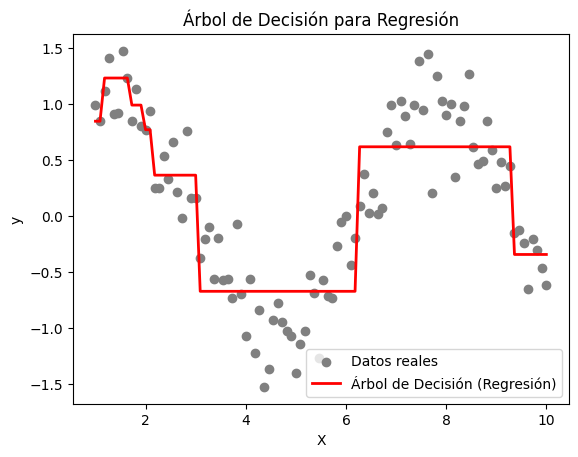

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# Generar datos sintéticos
np.random.seed(42)
X = np.linspace(1, 10, 100).reshape(-1, 1)
y = np.sin(X).ravel() + np.random.normal(scale=0.3, size=X.shape[0])

# Separar en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Entrenar el árbol de regresión
tree_reg = DecisionTreeRegressor(max_depth=3)
tree_reg.fit(X_train, y_train)

# Hacer predicciones
y_pred = tree_reg.predict(X_test)

# Evaluación del modelo
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Error Cuadrático Medio (MSE): {mse:.4f}")
print(f"Coeficiente de Determinación (R²): {r2:.4f}")

# Visualizar el ajuste del árbol
X_grid = np.linspace(1, 10, 100).reshape(-1, 1)
y_grid_pred = tree_reg.predict(X_grid)

plt.scatter(X, y, label="Datos reales", color="gray")
plt.plot(X_grid, y_grid_pred, label="Árbol de Decisión (Regresión)", color="red", linewidth=2)
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.title("Árbol de Decisión para Regresión")
plt.show()


Este código:  
✅ Genera datos sintéticos con ruido.  
✅ Entrena un árbol de regresión con `max_depth=3`.  
✅ Evalúa el modelo con **MSE y R²**.  
✅ Grafica la curva ajustada por el árbol de decisión.  

---

##  Conclusión
Los árboles de decisión de regresión son modelos potentes para predecir valores continuos sin necesidad de suponer relaciones lineales en los datos. Sin embargo, pueden ser **sensibles al sobreajuste**, por lo que es importante regularizar la profundidad del árbol y ajustar los hiperparámetros adecuadamente.
